## Consumo eléctrico - Multilayer Perceptron

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)
from sklearn.preprocessing import StandardScaler

In [63]:
df = pd.read_excel(
    r"electricidad.xlsx",
)


In [64]:
df.head()

,periodo,consumo
0,2025-01-01 00:00:00,55.467458
1,2025-01-01 01:00:00,56.468145
2,2025-01-01 02:00:00,58.643767
3,2025-01-01 03:00:00,62.734831
4,2025-01-01 04:00:00,65.757901


In [67]:
# ==========================
# Preparación de los datos
# ==========================

# Convertir la columna a tipo datetime
df["periodo"] = pd.to_datetime(df["periodo"])

# Ordenar por fecha
df = df.sort_values("periodo")

# Resetear los índices
df = df.reset_index(drop=True)

# (Opcional, pero recomendable para series temporales)
df = df.set_index("periodo")

In [ ]:
# Consumo electrico (Horas) = B0 + B1variable1 + B2variable2...
# Consumo electrico asociado a periodos que son horas
# Consumo(horas) = B0 + B1*Periodo

In [ ]:
### Consumo(t+1)=B0 + B1*consumo(t) + B2*consumo(t-1) +........+ otra inforamción disponible + x23 + x24

In [ ]:
# Feature Engineering
# Creamos los retardos para tener el valor del consumo en periodos anteriores

In [72]:
# Variables de retraso
df["lag_1"] = df["consumo"].shift(1)
df["lag_2"] = df["consumo"].shift(2)
df["lag_3"] = df["consumo"].shift(3)
df["lag_24"] = df["consumo"].shift(24)

# Variables temporales
df["hora"] = df.index.hour
df["dia_semana"] = df.index.dayofweek

# Eliminar nulos
df = df.dropna()

In [78]:
# Definir el conjunto X e Y

# Variables predictoras
X = df[[
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_24",
    "hora",
    "dia_semana"
]]

# Variable objetivo
y = df["consumo"]

In [79]:
# Creación dataset Train - Test

train_size = int(len(df) * 0.8) 
X_train = X.iloc[:train_size] 
X_test = X.iloc[train_size:] 
y_train = y.iloc[:train_size] 
y_test = y.iloc[train_size:]


In [81]:
# Estandarizar - normlizar

scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

In [82]:
# Modelo MLP 

modelo = MLPRegressor(
    hidden_layer_sizes=(64,32),
    activation="relu",
    solver="adam",
    max_iter=3000,
    learning_rate_init=0.001,
    random_state=42
)



In [83]:
# Entrenamiento

modelo.fit(X_train_scaled, y_train)

,loss,'squared_error'
,hidden_layer_sizes,"(64, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,3000
,shuffle,True


In [84]:
# Predicciónes 

predicciones_test = modelo.predict(X_test_scaled)


In [85]:
# ==========================
# Métricas
# ==========================

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predicciones_test
    )
)

mae = mean_absolute_error(
    y_test,
    predicciones_test
)

r2 = r2_score(
    y_test,
    predicciones_test
)

print(f"RMSE: {rmse:.2f}")
print(f"MAE : {mae:.2f}")
print(f"R²  : {r2:.4f}")

RMSE: 2.14
MAE : 1.75
R²  : 0.9664


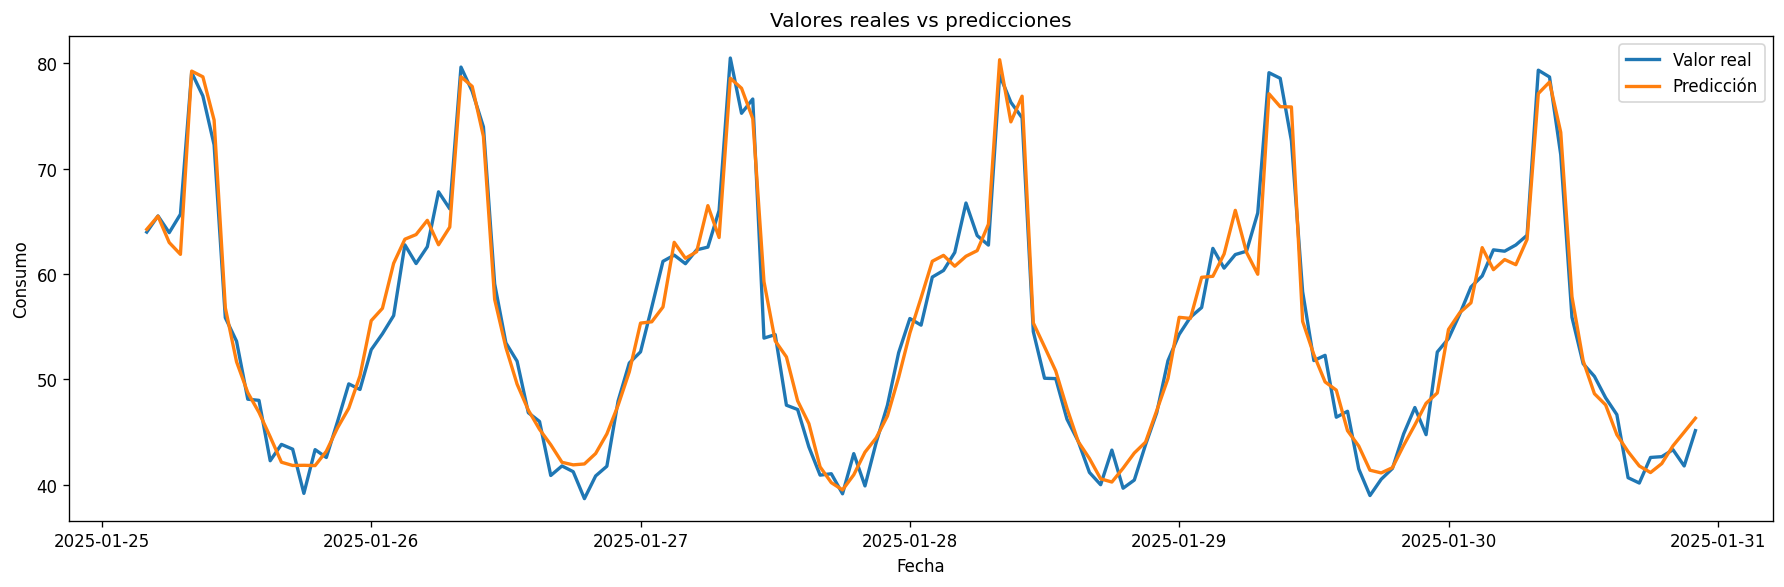

In [87]:
plt.figure(figsize=(15, 5), dpi=120)

plt.plot(
    y_test.index,
    y_test,
    label="Valor real",
    linewidth=2
)

plt.plot(
    y_test.index,
    predicciones_test,
    label="Predicción",
    linewidth=2
)

plt.title("Valores reales vs predicciones")
plt.xlabel("Fecha")
plt.ylabel("Consumo")
plt.legend()

plt.tight_layout()
plt.show()

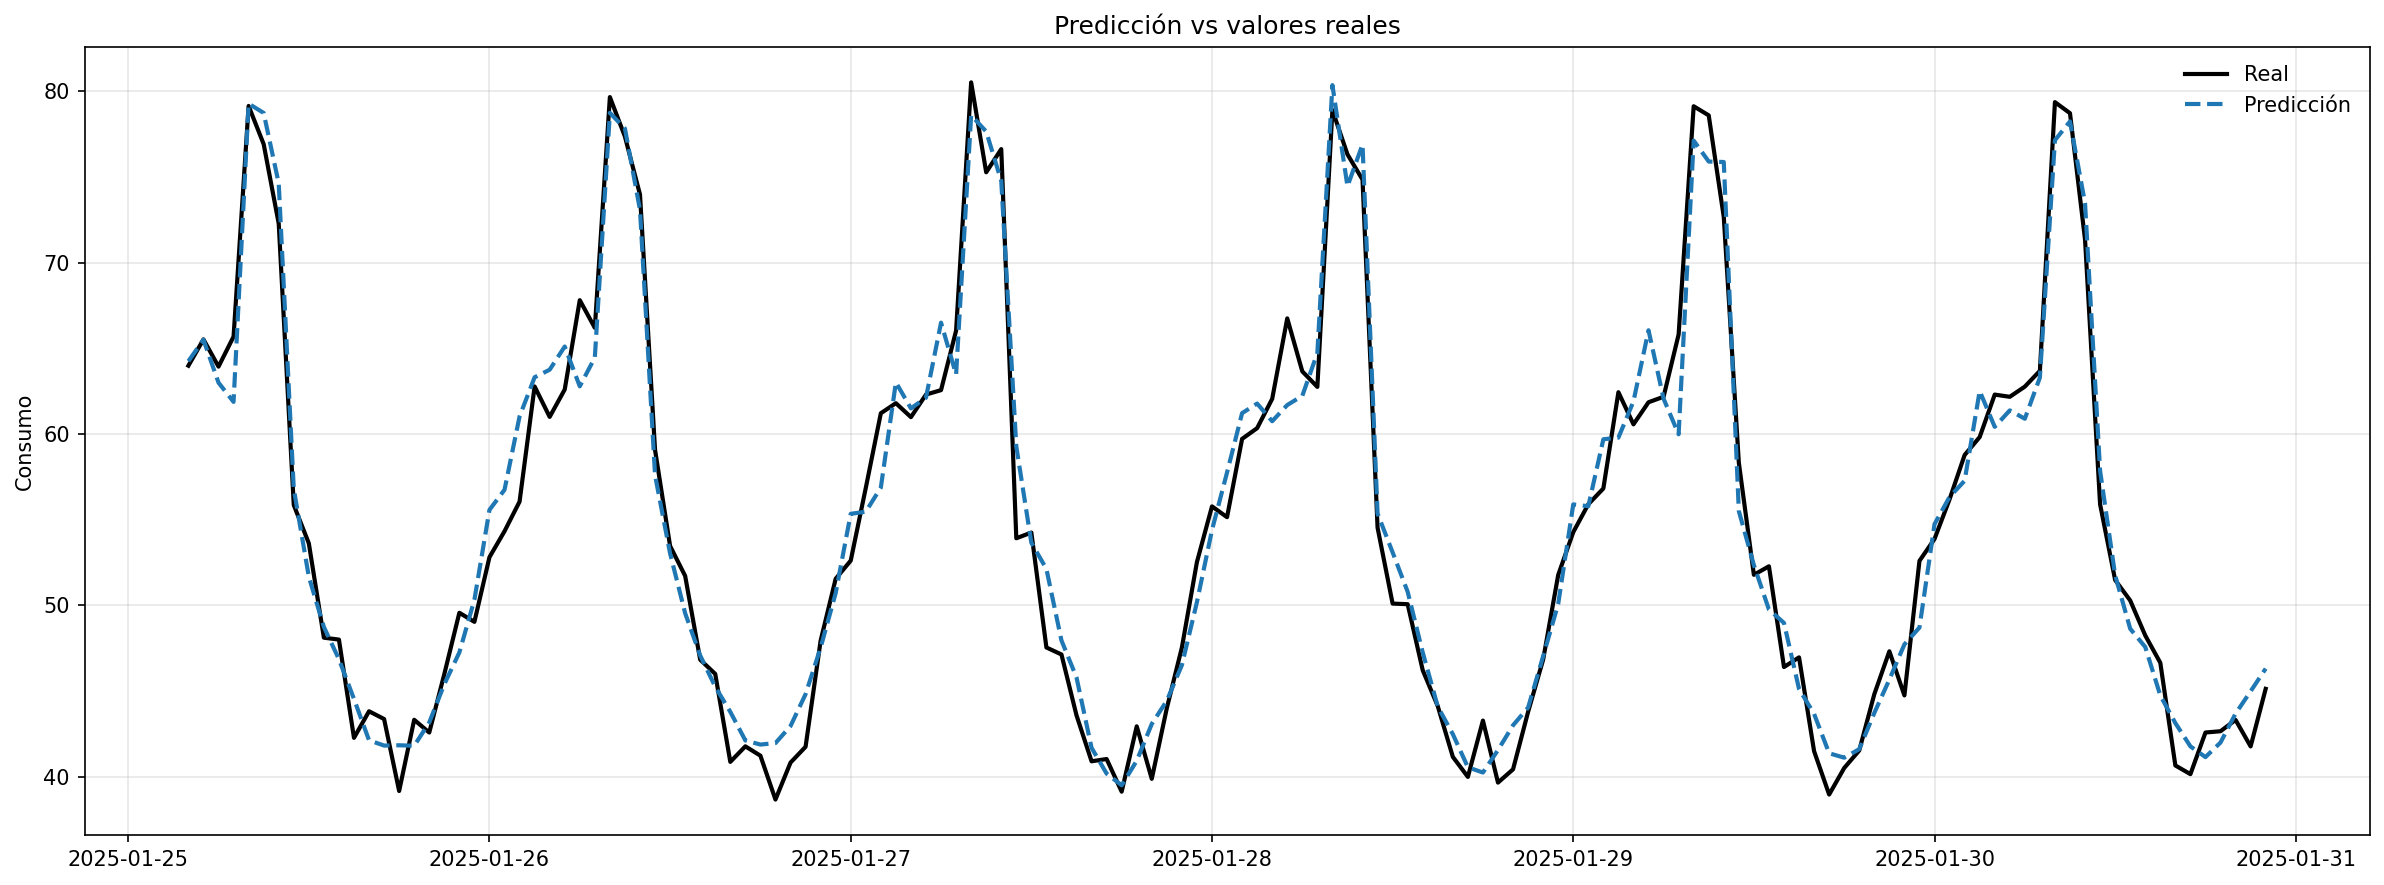

In [88]:
plt.figure(figsize=(16, 6), dpi=150)

plt.plot(
    y_test.index,
    y_test,
    color="black",
    linewidth=2,
    label="Real"
)

plt.plot(
    y_test.index,
    predicciones_test,
    color="tab:blue",
    linewidth=2,
    linestyle="--",
    label="Predicción"
)

plt.title("Predicción vs valores reales")
plt.xlabel("")
plt.ylabel("Consumo")
plt.grid(alpha=0.3)
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

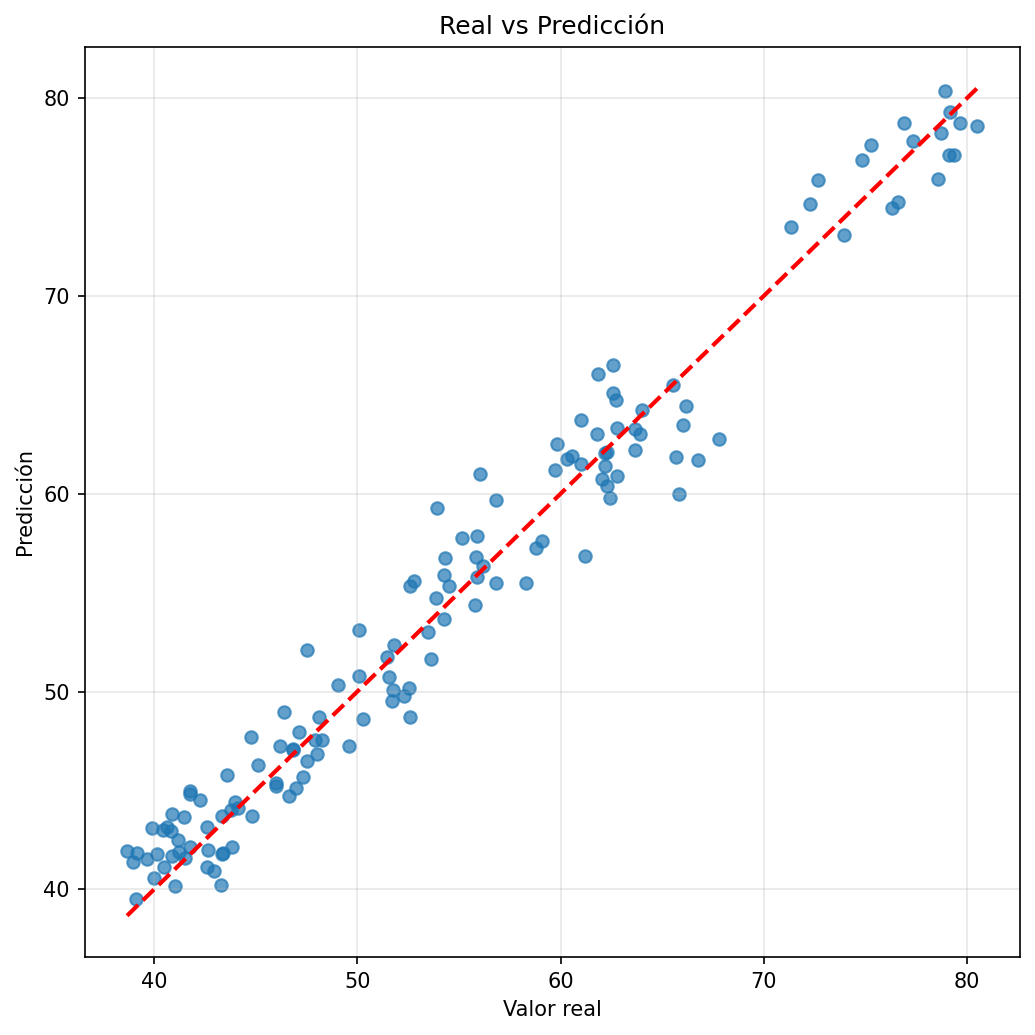

In [89]:
plt.figure(figsize=(7, 7), dpi=150)

plt.scatter(
    y_test,
    predicciones_test,
    alpha=0.7
)

xmin = min(y_test.min(), predicciones_test.min())
xmax = max(y_test.max(), predicciones_test.max())

plt.plot(
    [xmin, xmax],
    [xmin, xmax],
    "r--",
    linewidth=2
)

plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("Real vs Predicción")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

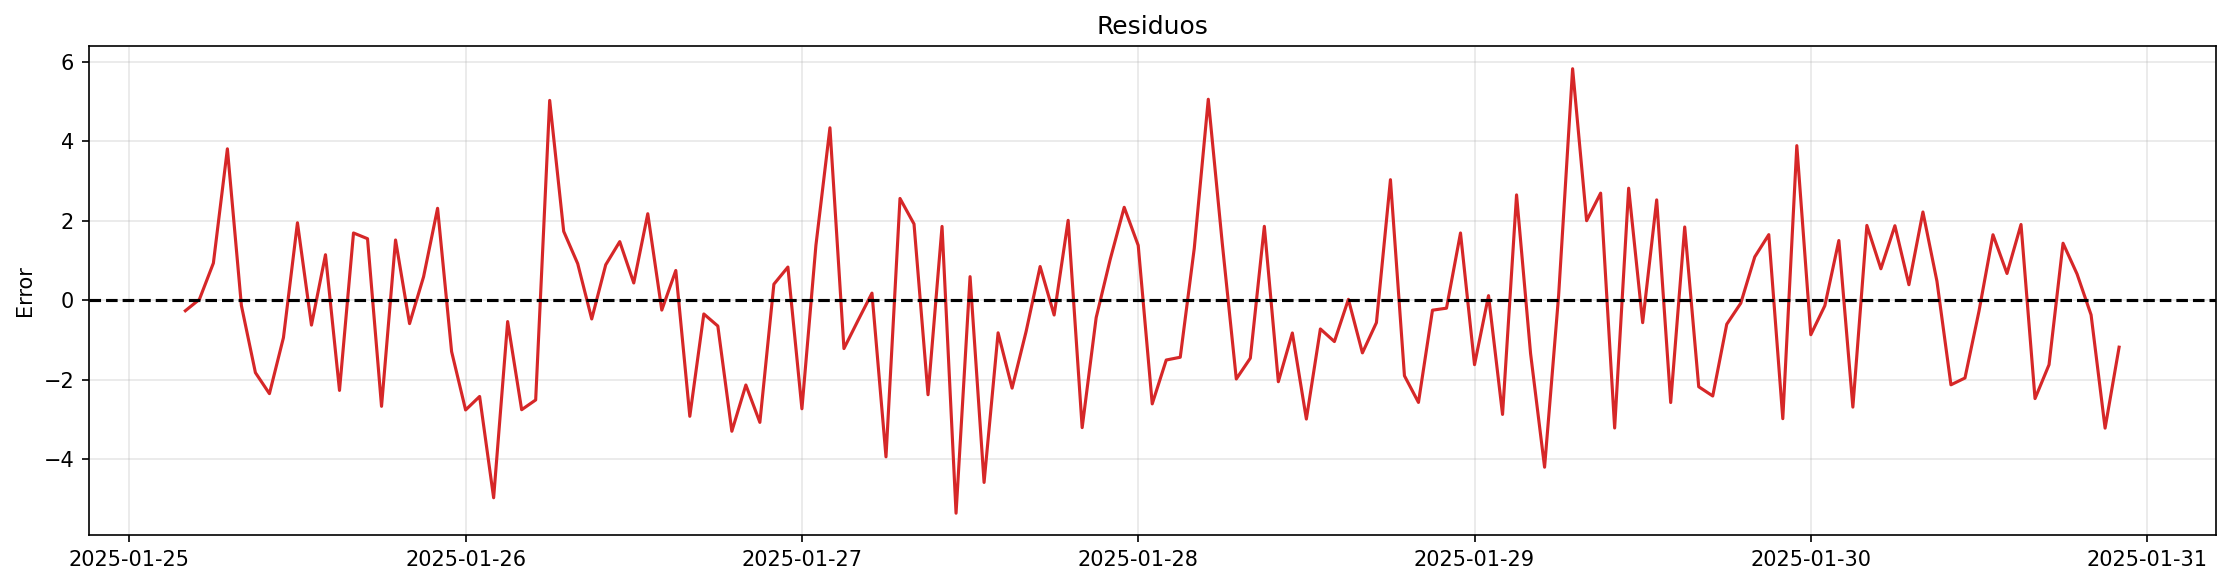

In [90]:
residuos = y_test - predicciones_test

plt.figure(figsize=(15, 4), dpi=150)

plt.plot(
    y_test.index,
    residuos,
    color="tab:red"
)

plt.axhline(
    0,
    color="black",
    linestyle="--"
)

plt.title("Residuos")
plt.ylabel("Error")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

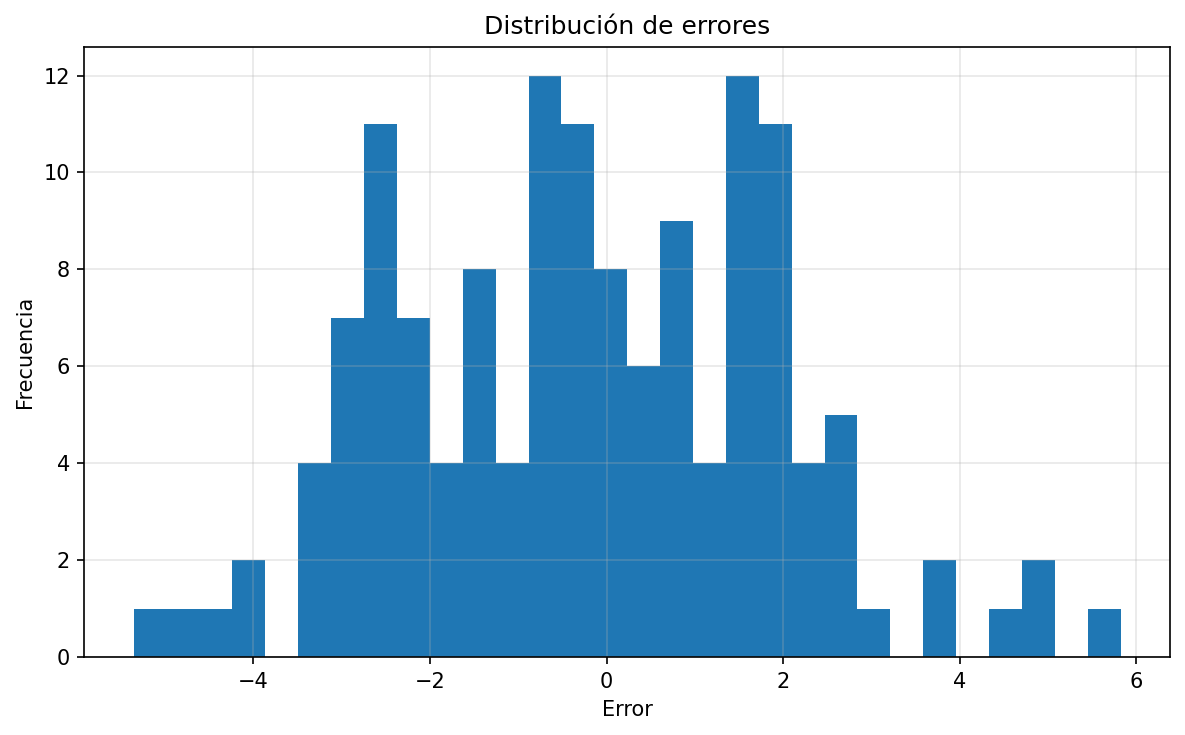

In [91]:
residuos = y_test - predicciones_test

plt.figure(figsize=(8,5), dpi=150)

plt.hist(
    residuos,
    bins=30
)

plt.title("Distribución de errores")
plt.xlabel("Error")
plt.ylabel("Frecuencia")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()